## Classification + regression on "Weather" dataset

This dataset is about millimeters of rainfall ("RainfallTomorrow") predictions.

---

In [1]:
import pandas as pd

df = pd.read_csv("hurdle_weather.csv")

df

,MinTemp,MaxTemp,Rainfall,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,...,WindGustDir_sin,WindGustDir_cos,WindDir9am_sin,WindDir9am_cos,WindDir3pm_sin,WindDir3pm_cos,Day,Year,Latitude,Longitude
0,13.4,22.9,0.6,44.0,20.0,24.0,71.0,22.0,1007.7,1007.1,...,-1.000000,-1.836970e-16,-1.000000,-1.836970e-16,-0.923880,3.826834e-01,336,2008,-36.0737,146.9135
1,7.4,25.1,0.0,44.0,4.0,22.0,44.0,25.0,1010.6,1007.8,...,-0.923880,3.826834e-01,-0.382683,9.238795e-01,-0.923880,-3.826834e-01,337,2008,-36.0737,146.9135
2,12.9,25.7,0.0,46.0,19.0,26.0,38.0,30.0,1007.6,1008.7,...,-0.923880,-3.826834e-01,-1.000000,-1.836970e-16,-0.923880,-3.826834e-01,338,2008,-36.0737,146.9135
3,9.2,28.0,0.0,24.0,11.0,9.0,45.0,16.0,1017.6,1012.8,...,0.707107,7.071068e-01,0.707107,-7.071068e-01,1.000000,6.123234e-17,339,2008,-36.0737,146.9135
4,17.5,32.3,1.0,41.0,7.0,20.0,82.0,33.0,1010.8,1006.0,...,-1.000000,-1.836970e-16,0.923880,3.826834e-01,-0.707107,7.071068e-01,340,2008,-36.0737,146.9135
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140780,3.5,21.8,0.0,31.0,15.0,13.0,59.0,27.0,1024.7,1021.2,...,1.000000,6.123234e-17,0.923880,-3.826834e-01,1.000000,6.123234e-17,171,2017,-25.3444,131.0369
140781,2.8,23.4,0.0,31.0,13.0,11.0,51.0,24.0,1024.6,1020.3,...,1.000000,6.123234e-17,0.707107,-7.071068e-01,0.923880,3.826834e-01,172,2017,-25.3444,131.0369
140782,3.6,25.3,0.0,22.0,13.0,9.0,56.0,21.0,1023.5,1019.1,...,-0.382683,9.238795e-01,0.707107,-7.071068e-01,0.000000,1.000000e+00,173,2017,-25.3444,131.0369
140783,5.4,26.9,0.0,37.0,9.0,9.0,53.0,24.0,1021.0,1016.8,...,0.000000,1.000000e+00,0.707107,-7.071068e-01,-0.923880,3.826834e-01,174,2017,-25.3444,131.0369


In [2]:
# Get column info

def get_column_info(df):
    """
    Returns a summary DataFrame with dtypes, null counts, 
    unique values for objects, and min/max for numeric columns.
    """
    summary_list = []
    
    for col in df.columns:

        # Basic info
        dtype = df[col].dtype
        null_count = df[col].isnull().sum()
        non_null_count = df[col].notnull().sum()
        
        unique_values = df[col].unique().tolist()
        min_val = None
        max_val = None
        
        # Info for numeric columns (Int/Float)
        if pd.api.types.is_numeric_dtype(dtype):
            min_val = df[col].min()
            max_val = df[col].max()
        else: # Sort categorical unique values
            unique_values = sorted(unique_values)
            
        summary_list.append({
            'Column': col,
            'Type': dtype,
            'Nulls': null_count,
            'Non-Nulls': non_null_count,
            'Unique Count': df[col].nunique(),
            'Unique Values': unique_values,
            'Min': min_val,
            'Max': max_val
        })
    
    return pd.DataFrame(summary_list).sort_values(by='Type')

get_column_info(df)

,Column,Type,Nulls,Non-Nulls,Unique Count,Unique Values,Min,Max
21,Year,int64,0,140785,11,"[2008, 2009, 2010, 2011, 2012, 2013, 2014, 201...",2007.0000,2017.0000
20,Day,int64,0,140785,366,"[336, 337, 338, 339, 340, 341, 342, 343, 344, ...",1.0000,366.0000
12,RainToday,int64,0,140785,2,"[0, 1]",0.0000,1.0000
0,MinTemp,float64,0,140785,622,"[13.4, 7.4, 12.9, 9.2, 17.5, 14.6, 14.3, 7.7, ...",-8.5000,33.9000
19,WindDir3pm_cos,float64,0,140785,12,"[0.38268343236509, -0.38268343236509, 6.123233...",-1.0000,1.0000
18,WindDir3pm_sin,float64,0,140785,10,"[-0.923879532511287, 1.0, -0.707106781186548, ...",-1.0000,1.0000
17,WindDir9am_cos,float64,0,140785,12,"[-1.83697019872103e-16, 0.923879532511287, -0....",-1.0000,1.0000
16,WindDir9am_sin,float64,0,140785,10,"[-1.0, -0.38268343236509, 0.707106781186548, 0...",-1.0000,1.0000
15,WindGustDir_cos,float64,0,140785,12,"[-1.83697019872103e-16, 0.38268343236509, -0.3...",-1.0000,1.0000
14,WindGustDir_sin,float64,0,140785,10,"[-1.0, -0.923879532511287, 0.707106781186548, ...",-1.0000,1.0000


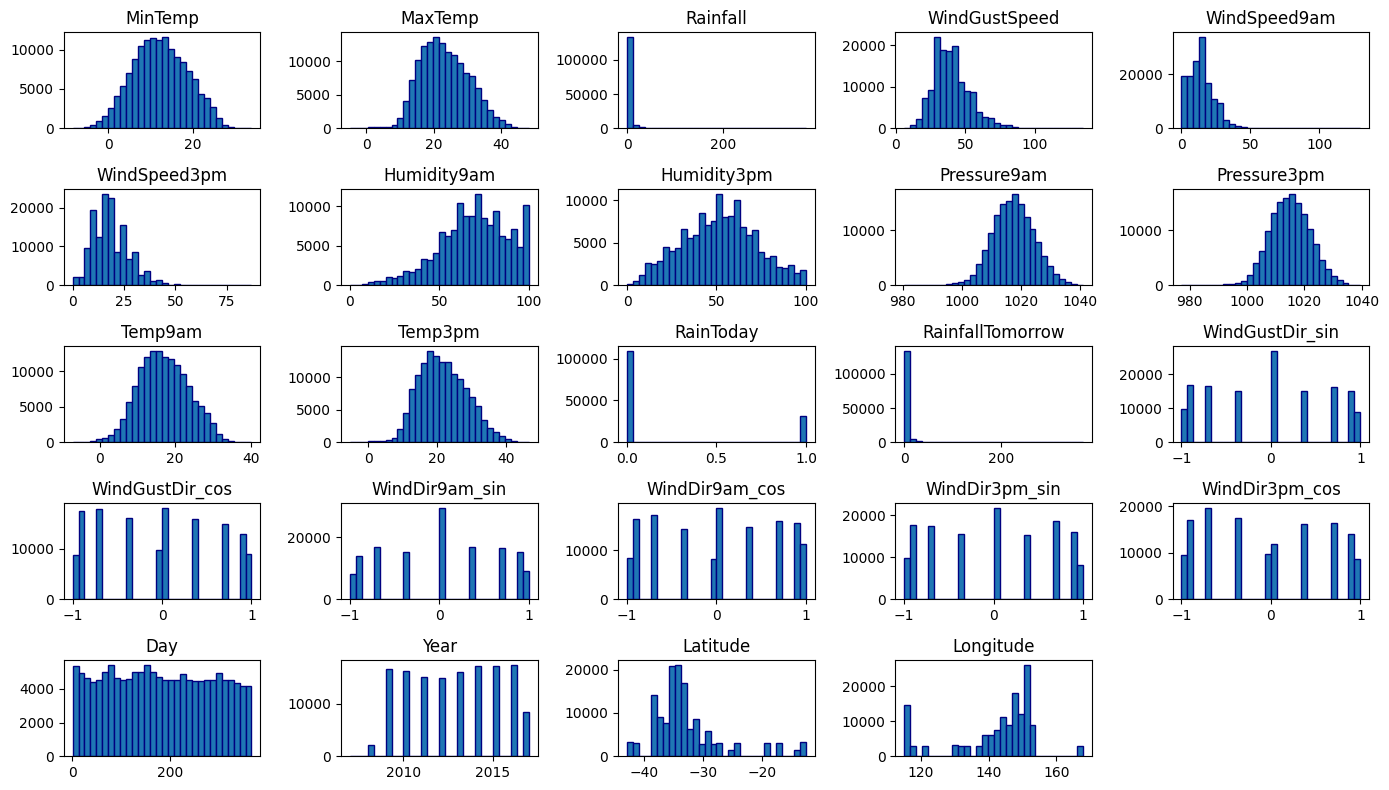

In [3]:
# Show histograms

import matplotlib.pyplot as plt

def plot_histograms(df):
    '''Print histogram for all columns'''
    df.hist(figsize=(14, 8), bins=30, edgecolor='navy', grid=False)
    plt.tight_layout()
    plt.show()

plot_histograms(df)

In [6]:
target_column = "RainfallTomorrow"
other_columns_to_drop = []

y = df[target_column]
X = df.drop(columns=[target_column, *other_columns_to_drop])

display(X, y)

,MinTemp,MaxTemp,Rainfall,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,...,WindGustDir_sin,WindGustDir_cos,WindDir9am_sin,WindDir9am_cos,WindDir3pm_sin,WindDir3pm_cos,Day,Year,Latitude,Longitude
0,13.4,22.9,0.6,44.0,20.0,24.0,71.0,22.0,1007.7,1007.1,...,-1.000000,-1.836970e-16,-1.000000,-1.836970e-16,-0.923880,3.826834e-01,336,2008,-36.0737,146.9135
1,7.4,25.1,0.0,44.0,4.0,22.0,44.0,25.0,1010.6,1007.8,...,-0.923880,3.826834e-01,-0.382683,9.238795e-01,-0.923880,-3.826834e-01,337,2008,-36.0737,146.9135
2,12.9,25.7,0.0,46.0,19.0,26.0,38.0,30.0,1007.6,1008.7,...,-0.923880,-3.826834e-01,-1.000000,-1.836970e-16,-0.923880,-3.826834e-01,338,2008,-36.0737,146.9135
3,9.2,28.0,0.0,24.0,11.0,9.0,45.0,16.0,1017.6,1012.8,...,0.707107,7.071068e-01,0.707107,-7.071068e-01,1.000000,6.123234e-17,339,2008,-36.0737,146.9135
4,17.5,32.3,1.0,41.0,7.0,20.0,82.0,33.0,1010.8,1006.0,...,-1.000000,-1.836970e-16,0.923880,3.826834e-01,-0.707107,7.071068e-01,340,2008,-36.0737,146.9135
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140780,3.5,21.8,0.0,31.0,15.0,13.0,59.0,27.0,1024.7,1021.2,...,1.000000,6.123234e-17,0.923880,-3.826834e-01,1.000000,6.123234e-17,171,2017,-25.3444,131.0369
140781,2.8,23.4,0.0,31.0,13.0,11.0,51.0,24.0,1024.6,1020.3,...,1.000000,6.123234e-17,0.707107,-7.071068e-01,0.923880,3.826834e-01,172,2017,-25.3444,131.0369
140782,3.6,25.3,0.0,22.0,13.0,9.0,56.0,21.0,1023.5,1019.1,...,-0.382683,9.238795e-01,0.707107,-7.071068e-01,0.000000,1.000000e+00,173,2017,-25.3444,131.0369
140783,5.4,26.9,0.0,37.0,9.0,9.0,53.0,24.0,1021.0,1016.8,...,0.000000,1.000000e+00,0.707107,-7.071068e-01,-0.923880,3.826834e-01,174,2017,-25.3444,131.0369


0         0.0
1         0.0
2         0.0
3         1.0
4         0.2
         ... 
140780    0.0
140781    0.0
140782    0.0
140783    0.0
140784    0.0
Name: RainfallTomorrow, Length: 140785, dtype: float64

In [7]:
# Check categorical columns

def get_all_categories(df):
    """Get names and unique values for every column with type 'object'"""

    obj_cols = df.select_dtypes(include=['object']).columns
    data = []

    for col in obj_cols:
        data.append({
            'column_name': col,
            'unique_values': df[col].unique().tolist(),
            'value_count': len(df[col].unique()),
        })
    
    return pd.DataFrame(data)

get_all_categories(X)

""


In [ ]:
# Option 1: encode manually with map + convert to categories

'''
# Map categories to integers manually
area_mapping = {"A": 0, "B": 1, "C": 2, "D": 3, "E": 4, "F": 5}
gas_mapping = {"Regular": 0, "Diesel": 1}

# For high-cardinality nominal columns, we can automate the mapping dictionary
region_mapping = {val: i for i, val in enumerate(df["Region"].unique())}
brand_mapping = {val: i for i, val in enumerate(df["VehBrand"].unique())}

# --- STEP 2: Apply .map() AND set to 'category' ---
# We map the strings to integers, then immediately cast to the 'category' dtype

X_encoded = X.copy()
X_encoded["Area"] = X_encoded["Area"].map(area_mapping).astype("category")
X_encoded["VehGas"] = X_encoded["VehGas"].map(gas_mapping).astype("category")
X_encoded["Region"] = X_encoded["Region"].map(region_mapping).astype("category")
X_encoded["VehBrand"] = X_encoded["VehBrand"].map(brand_mapping).astype("category")

X_encoded
'''

In [ ]:
# X_encoded.info()

In [10]:
# Option 2: Encode with ordinal encoder + convert to categories

# from sklearn.preprocessing import OrdinalEncoder

# def encode_categorical_columns(df: pd.DataFrame, categorical_columns: list[str]) -> pd.DataFrame:
#     '''Convert categorical columns into Int64 categories'''
#     encoder = OrdinalEncoder(dtype=int, handle_unknown='use_encoded_value', unknown_value=-1).set_output(transform="pandas")

#     encoded_cols = encoder.fit_transform(X[categorical_columns]).astype('category')

#     df_encoded = df.copy()
#     df_encoded[categorical_columns] = encoded_cols
#     return df_encoded

# cat_cols = ['VehBrand', 'VehGas', 'Area', 'Region']
# X_encoded_2 = encode_categorical_columns(X, cat_cols)

# display(X_encoded_2.info(), X_encoded_2)

In [11]:
# Split dataset

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


# Scale X data

cols_to_scale = X_train.columns

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().set_output(transform="pandas")
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

display(X_train, X_test)

,MinTemp,MaxTemp,Rainfall,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,...,WindGustDir_sin,WindGustDir_cos,WindDir9am_sin,WindDir9am_cos,WindDir3pm_sin,WindDir3pm_cos,Day,Year,Latitude,Longitude
96803,-0.606131,-0.314533,-0.275879,-0.072707,0.677343,0.590272,-0.304390,-0.598464,1.199922,0.964374,...,0.025387,1.544683,-0.025522,1.423961,-0.519101,1.402167,0.539356,-0.693045,-0.838036,-0.105956
81997,0.878583,0.726373,-0.275879,-0.897242,-0.789564,-0.875921,-0.827722,-0.308468,0.088579,0.103117,...,1.477358,0.067200,0.545604,-1.344848,1.448835,0.065745,-1.695360,-0.299442,0.871551,0.908847
4852,-1.653246,-1.200711,-0.275879,-0.522453,-0.563886,-1.327058,-0.775389,-0.646797,1.214170,1.380648,...,-0.530258,-1.297816,-1.080825,-1.032873,1.448835,0.065745,0.415205,0.487765,-0.189157,0.720283
9793,-0.309189,-0.342666,-0.275879,-0.072707,-0.902403,1.041409,-0.095057,0.416524,1.698602,1.481128,...,0.581033,1.432217,-1.080825,1.002435,1.031968,1.088598,0.653957,-0.693045,0.404862,0.916862
3870,-0.559246,-0.736523,-0.275879,-1.346988,-0.563886,-0.650353,0.218942,0.609855,0.573011,0.347140,...,1.477358,0.067200,-1.080825,-1.032873,1.448835,0.065745,0.682607,-0.693045,-0.189157,0.720283
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111182,-0.606131,1.106163,-0.275879,-0.897242,0.113148,-1.439842,-1.769721,-1.565119,0.829475,0.605517,...,0.581033,1.432217,1.029781,1.002435,-1.397711,0.065745,-0.587552,-1.086649,0.178887,-2.158871
130188,-0.871817,-0.033207,-0.275879,0.601913,-1.353760,0.815841,0.428275,-0.405133,-0.923028,-1.160059,...,-0.530258,1.432217,-0.025522,1.423961,-0.519101,1.402167,1.083710,0.094162,-1.432995,0.422442
102641,1.519355,0.627909,-0.275879,0.227124,0.338826,-0.875921,1.108607,1.141515,-1.236483,-1.088287,...,0.581033,1.432217,1.466902,-0.015219,1.448835,0.065745,-1.074605,-0.693045,0.261408,-0.436092
46108,-1.918932,-1.369506,-0.275879,-1.871693,-0.338208,-1.439842,0.951608,0.223193,1.299658,1.251459,...,1.052086,-0.977538,1.029781,-1.032873,0.025562,1.512278,0.224204,0.487765,-0.417608,0.585972


,MinTemp,MaxTemp,Rainfall,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,...,WindGustDir_sin,WindGustDir_cos,WindDir9am_sin,WindDir9am_cos,WindDir3pm_sin,WindDir3pm_cos,Day,Year,Latitude,Longitude
24479,-1.262532,-0.539594,-0.275879,-0.897242,-1.579438,-0.650353,0.689941,-0.453466,-0.860086,-0.853966,...,-0.530258,-1.297816,-0.025522,-0.015219,0.025562,-1.380789,-0.415651,-0.299442,-0.165127,0.715633
29203,1.066126,0.487246,-0.275879,-0.175793,-0.338208,0.139136,0.218942,0.319858,0.843723,0.720351,...,0.025387,0.067200,-0.025522,1.423961,1.340495,0.619309,-0.969554,-1.873856,-0.184552,0.758331
28155,-0.387331,-0.159804,-0.275879,-0.672369,-1.128081,-1.327058,-0.304390,-0.743463,2.140290,1.796922,...,1.477358,0.067200,-0.025522,-1.454400,0.570225,1.402167,0.816308,0.487765,-0.140189,0.723018
54820,-1.012474,-1.580501,-0.275879,0.227124,0.564504,0.364704,0.480609,0.368191,1.513378,1.667733,...,1.052086,-0.977538,0.545604,-1.344848,1.031968,-0.957109,-0.501601,0.487765,-0.794118,0.148325
60925,-0.996846,-1.228843,-0.275879,-0.672369,0.338826,0.590272,0.742275,0.464856,1.527626,1.796922,...,-1.426583,0.067200,-1.517946,-0.015219,-1.397711,0.065745,0.195554,0.487765,-0.884809,0.415214
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51769,-0.231046,-1.411705,-0.275879,-0.222622,0.113148,-0.424785,1.474940,2.301501,-0.696638,-0.565877,...,-1.316059,-0.498208,-1.404342,0.535531,-1.289371,-0.487820,-0.826303,0.487765,-0.459265,0.557233
106742,-0.027874,-0.595860,-0.134725,-0.236728,-0.789564,-0.875921,0.480609,1.383179,-0.752052,-0.528471,...,0.025387,0.067200,-0.596648,1.314410,-1.397711,0.065745,-0.310600,0.487765,-0.375011,-2.004302
116488,-0.059131,-0.792788,0.429888,1.426448,0.338826,-0.199216,0.218942,0.174860,-0.552580,-0.054780,...,-1.001311,-0.977538,-1.080825,-1.032873,-0.980844,-0.957109,0.739908,-1.873856,0.131767,-2.171952
134807,1.566240,1.584418,-0.275879,-0.747326,0.903021,-0.199216,0.323609,-1.130125,-1.094004,-1.274893,...,0.025387,-1.410282,-0.025522,-1.454400,-0.519101,-1.270678,-0.969554,-1.480252,3.348236,-0.929667


In [13]:
# Utility functions

def show_correlation_matrix(df: pd.DataFrame):
    """
    Pure Matplotlib heatmap with automated text coloring for readability.
    """
    import matplotlib.pyplot as plt
    import numpy as np

    corr = df.corr()
    fig, ax = plt.subplots(figsize=(10, 8))

    # Use 'RdBu_r' (reversed) so Red is positive, Blue is negative
    im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
    plt.colorbar(im)

    # Labels
    ticks = np.arange(len(corr.columns))
    ax.set_xticks(ticks)
    ax.set_xticklabels(corr.columns, rotation=45, ha="right")
    ax.set_yticks(ticks)
    ax.set_yticklabels(corr.columns)

    # Add text annotations with contrast logic
    for i in range(len(corr.columns)):
        for j in range(len(corr.columns)):
            val = corr.iloc[i, j]
            # Use white text for very dark colors (strong correlations)
            color = "white" if abs(val) > 0.7 else "black"
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", color=color)

    ax.set_title("Correlation Matrix")
    fig.tight_layout()
    plt.show()

import matplotlib.pyplot as plt
from sklearn.model_selection import LearningCurveDisplay
import numpy as np

def plot_learning_curve(model, X, y, classification: bool, cv=5):
    """
    Displays data size vs score. LearningCurveDisplay uses matplotlib under the hood.
    """

    display = LearningCurveDisplay.from_estimator(
        model,
        X,
        y,
        cv=cv,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring="accuracy" if classification else "r2",
    )
    display.ax_.set_title(f"Learning Curve: {model.__class__.__name__}")
    display.ax_.grid(True, linestyle="--", alpha=0.6)
    plt.show()

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
def show_confusion_matrix(model, y_test, y_pred):
    """Standard confusion matrix plot using Matplotlib backend."""
    if not hasattr(model, "classes_"):
        print("Model does not have classes_ attribute.")
        return

    cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot(
        cmap="Blues", values_format=".4g"
    )  # values_format prevents scientific notation
    plt.title(f"Confusion Matrix: {model.__class__.__name__}")
    plt.show()


from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score
def get_regression_metrics(y_test, y_pred) -> pd.DataFrame:
    """Calculates regression metrics"""
    metrics = {
        "Metric": ["MAE", "MSE", "RMSE", "R2 Score"],
        "Value": [
            mean_absolute_error(y_test, y_pred),
            mean_squared_error(y_test, y_pred),
            root_mean_squared_error(y_test, y_pred),
            r2_score(y_test, y_pred),
        ],
    }
    return pd.DataFrame(metrics).style.format({ "Value": "{:,.2f}" }) # Round to 2 decimals


from sklearn.metrics import classification_report
def get_classification_report(y_true, y_pred, target_names: list[str] | None = None) -> pd.DataFrame:
    """Converts sklearn report to a DataFrame."""
    report_dict = classification_report(y_true, y_pred, target_names=target_names, output_dict=True)
    return pd.DataFrame(report_dict).transpose().round(2)


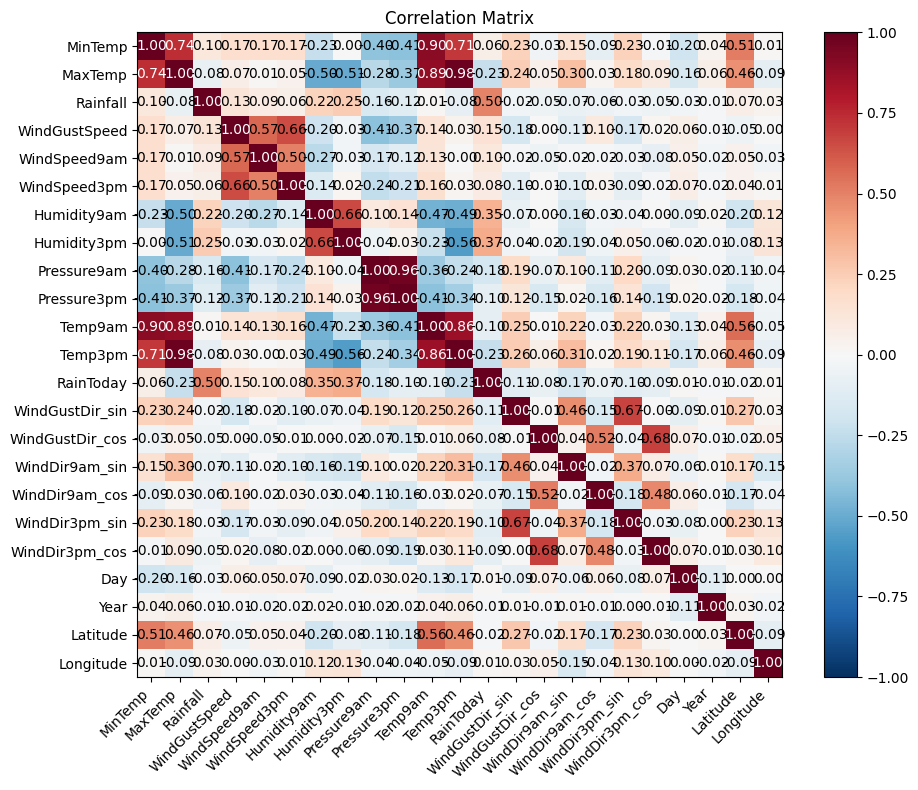

In [14]:
show_correlation_matrix(X_train)

In [ ]:
# Part 1: train regressor on the entire dataset

In [15]:
# Grid search on regressor (entire training data)

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import HistGradientBoostingRegressor

param_grid = {
    # 'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_iter': [100, 200, 400],
    'max_leaf_nodes': [15, 31, 63],
    'min_samples_leaf': [50, 100, 200],
    'l2_regularization': [0.0, 0.5, 1.0, 5.0],
    'early_stopping': [True],
}

grid_search = GridSearchCV(HistGradientBoostingRegressor(), param_grid=param_grid, n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)

Best params: {'early_stopping': True, 'l2_regularization': 0.5, 'max_iter': 400, 'max_leaf_nodes': 31, 'min_samples_leaf': 100}
Best score: 0.37193159361757394


In [28]:
# Train regressor on the entire training data

from sklearn.ensemble import HistGradientBoostingRegressor

best_params = {'early_stopping': True, 'l2_regularization': 0.5, 'max_iter': 400, 'max_leaf_nodes': 31, 'min_samples_leaf': 100}

# Initialize the model
# 'from_dtype' tells the model to treat anything we marked as .astype('category') correctly
model = HistGradientBoostingRegressor(**best_params, categorical_features="from_dtype")

# Fit the model
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Fix negative predictions by replacing them with zero
y_pred = np.where(y_pred < 0, 0, y_pred)

# Check accuracy
get_regression_metrics(y_test, y_pred)

,Metric,Value
0,MAE,2.36
1,MSE,48.58
2,RMSE,6.97
3,R2 Score,0.36


In [31]:
# We can check the predicions manually if we want

pd.DataFrame({
    "y_test": y_test,
    "y_pred": y_pred,
    "error": round(y_pred - y_test, 1),
})

,y_test,y_pred,error
24479,0.2,0.307211,0.1
29203,0.0,1.053477,1.1
28155,0.0,0.194827,0.2
54820,0.0,0.146189,0.1
60925,0.2,0.033562,-0.2
...,...,...,...
51769,35.0,5.072273,-29.9
106742,3.4,5.520520,2.1
116488,0.0,2.557974,2.6
134807,0.0,0.655857,0.7


In [ ]:
# Part 2a: train classifier on entire dataset

In [32]:
# Convert target column from float to 0/1
y_train_class = (y_train>0).astype(int)
y_test_class = (y_test>0).astype(int)

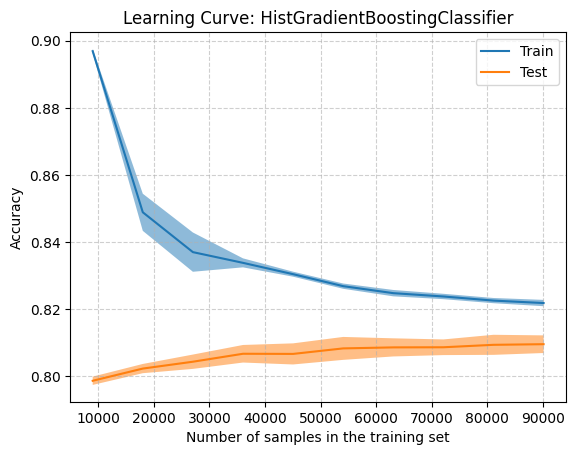

In [33]:
from sklearn.ensemble import HistGradientBoostingClassifier

model = HistGradientBoostingClassifier()
plot_learning_curve(model, X_train, y_train_class, classification=True)

In [34]:
# Grid search on classifier

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    # 'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_iter': [100, 200, 400],
    'max_leaf_nodes': [15, 31, 63],
    'min_samples_leaf': [50, 100, 200],
    'l2_regularization': [0.0, 0.5, 1.0],
    'early_stopping': [True],
    'class_weight': ['balanced', None],
}

grid_search = GridSearchCV(HistGradientBoostingClassifier(), param_grid=param_grid, n_jobs=-1)
grid_search.fit(X_train, y_train_class)

print("Best params:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)

Best params: {'class_weight': None, 'early_stopping': True, 'l2_regularization': 0.5, 'max_iter': 400, 'max_leaf_nodes': 63, 'min_samples_leaf': 200}
Best score: 0.8170081944524237


In [35]:
best_params = {'class_weight': None, 'early_stopping': True, 'l2_regularization': 0.5, 'max_iter': 400, 'max_leaf_nodes': 63, 'min_samples_leaf': 200}

# Initialize the model
# 'from_dtype' tells the model to treat anything we marked as .astype('category') correctly
model = HistGradientBoostingClassifier(**best_params, categorical_features="from_dtype")

# Fit the model
model.fit(X_train, y_train_class)
y_pred_class = model.predict(X_test)

# Check accuracy
get_classification_report(y_test_class, y_pred_class)

,precision,recall,f1-score,support
0,0.82,0.89,0.86,17915.00
1,0.78,0.67,0.72,10242.00
accuracy,0.81,0.81,0.81,0.81
macro avg,0.80,0.78,0.79,28157.00
weighted avg,0.81,0.81,0.81,28157.00


In [36]:
# Check results
pd.DataFrame({
    "y_test": y_test_class,
    "y_pred (classifier)": y_pred_class,
    "correct?": y_pred_class == y_test_class,
})

,y_test,y_pred (classifier),correct?
24479,1,0,False
29203,0,0,True
28155,0,0,True
54820,0,0,True
60925,1,0,False
...,...,...,...
51769,1,1,True
106742,1,1,True
116488,0,1,False
134807,0,0,True


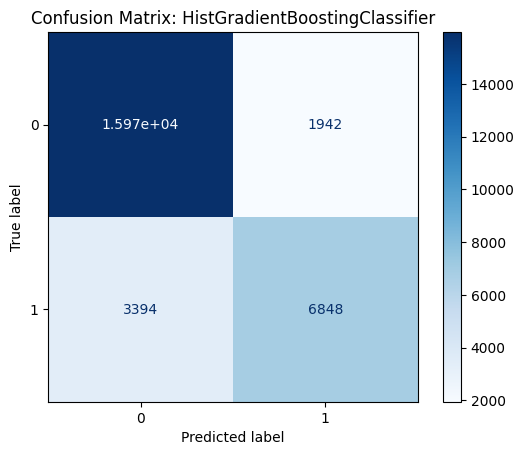

In [37]:
show_confusion_matrix(model, y_test_class, y_pred_class)

In [ ]:
# Part 2b: train regressor on but only on rows where y > 0

In [38]:
# Filter rows where y > 0
X_train_regr = X_train[y_train > 0]
y_train_regr = y_train[y_train > 0]

In [39]:
# Grid search on regressor

from sklearn.model_selection import GridSearchCV

param_grid = {
    # 'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_iter': [200, 400],
    'max_leaf_nodes': [31, 63],
    'min_samples_leaf': [100, 200],
    'l2_regularization': [0.0, 0.5, 1.0],
    'early_stopping': [True],
}

grid_search = GridSearchCV(HistGradientBoostingRegressor(), param_grid=param_grid, n_jobs=-1)
grid_search.fit(X_train_regr, y_train_regr)

print("Best params:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)

Best params: {'early_stopping': True, 'l2_regularization': 1.0, 'max_iter': 200, 'max_leaf_nodes': 31, 'min_samples_leaf': 100}
Best score: 0.31606657565767515


In [40]:
from sklearn.ensemble import HistGradientBoostingRegressor

best_params = {'early_stopping': True, 'l2_regularization': 1.0, 'max_iter': 200, 'max_leaf_nodes': 31, 'min_samples_leaf': 100}

# Initialize the model
# 'from_dtype' tells the model to treat anything we marked as .astype('category') correctly
model = HistGradientBoostingRegressor(**best_params, categorical_features="from_dtype")

# Fit the model
model.fit(X_train_regr, y_train_regr)
y_pred_regr = model.predict(X_test)

# Check accuracy (on the full unfiltered train data)
get_regression_metrics(y_test, y_pred_regr)

,Metric,Value
0,MAE,3.80
1,MSE,53.45
2,RMSE,7.31
3,R2 Score,0.30


In [ ]:
# Part 3: combine the two predictions (classifier + regressor)

In [41]:
import numpy as np

y_pred_combined = np.where(y_pred_class == 0, 0, y_pred_regr)

# Check the results: classifier, regressor, combined
pd.DataFrame({
    "y_test": y_test,
    "y_pred (classifier)": y_pred_class,
    "y_pred (regressor)": y_pred_regr,
    "y_pred (combined)": y_pred_combined,
})

,y_test,y_pred (classifier),y_pred (regressor),y_pred (combined)
24479,0.2,0,2.361988,0.000000
29203,0.0,0,5.347421,0.000000
28155,0.0,0,1.462507,0.000000
54820,0.0,0,0.393058,0.000000
60925,0.2,0,0.549847,0.000000
...,...,...,...,...
51769,35.0,1,9.641239,9.641239
106742,3.4,1,6.154686,6.154686
116488,0.0,1,3.649642,3.649642
134807,0.0,0,3.819265,0.000000


In [42]:
get_regression_metrics(y_test, y_pred_combined)

,Metric,Value
0,MAE,2.22
1,MSE,48.62
2,RMSE,6.97
3,R2 Score,0.36
